# Distribution check

checking the distributional assumption of the parametric AFT model

In [ ]:
import lifelines
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from lifelines import (
    LogLogisticFitter,
    LogNormalFitter,
    WeibullFitter,
)
from ic_qq_plot import qq_plot

## Load data

In [10]:
deciduous_teeth = pd.read_csv(
    "../data/deciduous_teeth_fully_cleaned_noinfo.csv", sep=";", index_col="Unnamed: 0"
)

In [11]:
permanent_teeth = pd.read_csv(
    "../data/permanent_teeth_fully_cleaned_noinfo.csv", sep=";", index_col="Unnamed: 0"
)

In [12]:
permanent_teeth.drop(columns="index", inplace=True)

## Preprocess

In [13]:
def preprocess_data(df):
    df.loc[((df["LOWER"].isna()), "LOWER")] = 0
    df.loc[((df["UPPER"].isna()), "UPPER")] = np.inf
    df = df.rename(
        columns={
            "TOOTH NUMBER": "TOOTH_NUMBER",
            "DEVELOPM STAGE": "DEVELOPM_STAGE",
            "MAX/MAND": "MAX_MAND",
            "SIDE (L/R)": "SIDE",
            "BREED SIZE": "BREED_SIZE",
            "SKULL TYPE": "SKULL_TYPE",
            "BREED CLADE": "BREED_CLADE",
        }
    )
    return df

In [14]:
deciduous_teeth = preprocess_data(deciduous_teeth)
permanent_teeth = preprocess_data(permanent_teeth)

## QQ plots + AIC

AIC for WeibullFitter is 120597.2818485532
AIC for LogLogisticFitter is 117394.84096212414
AIC for LogNormalFitter is 117764.2116542385


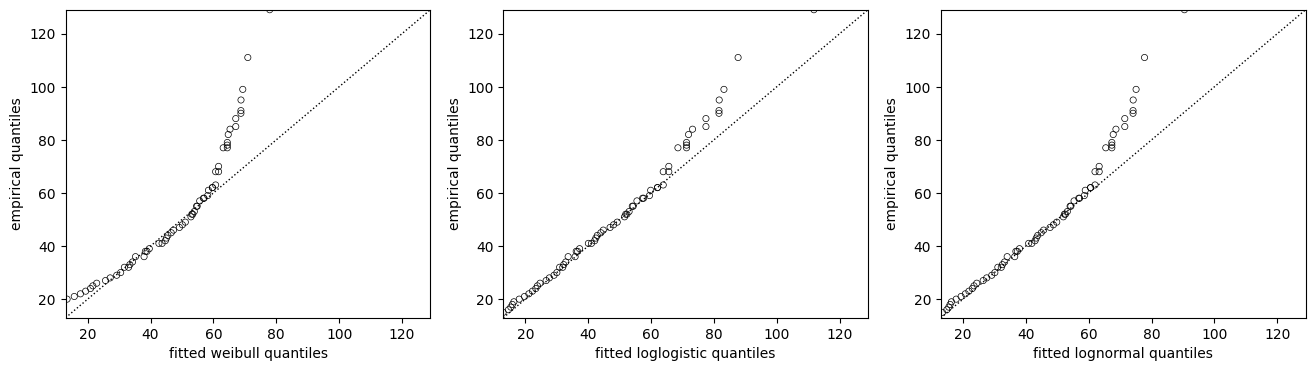

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, model in enumerate([WeibullFitter(), LogLogisticFitter(), LogNormalFitter()]):
    model.fit_interval_censoring(deciduous_teeth["LOWER"], deciduous_teeth["UPPER"])
    print(f"AIC for {model._class_name} is {model.AIC_}")
    qq_plot(model, ax=axes[i])

AIC for WeibullFitter is 181352.70693033037
AIC for LogLogisticFitter is 180841.22192300466
AIC for LogNormalFitter is 180150.81969484


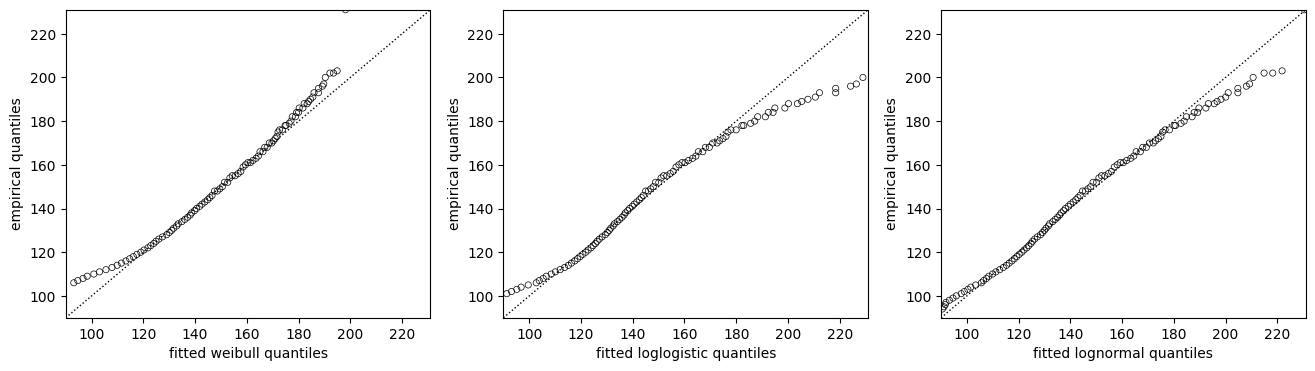

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, model in enumerate([WeibullFitter(), LogLogisticFitter(), LogNormalFitter()]):
    model.fit_interval_censoring(permanent_teeth["LOWER"], permanent_teeth["UPPER"])
    print(f"AIC for {model._class_name} is {model.AIC_}")
    qq_plot(model, ax=axes[i])